In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [9]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [10]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)


In [11]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [12]:
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [13]:
print("NAV Missing Values")
print(nav.isnull().sum())

print("\nBenchmark Missing Values")
print(benchmark.isnull().sum())

NAV Missing Values
amfi_code    0
date         0
nav          0
dtype: int64

Benchmark Missing Values
date           0
index_name     0
close_value    0
dtype: int64


In [14]:
print("Unique Mutual Funds")

print(nav["amfi_code"].nunique())

Unique Mutual Funds
40


In [15]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [16]:
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [17]:
# Summary statistics of daily returns
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

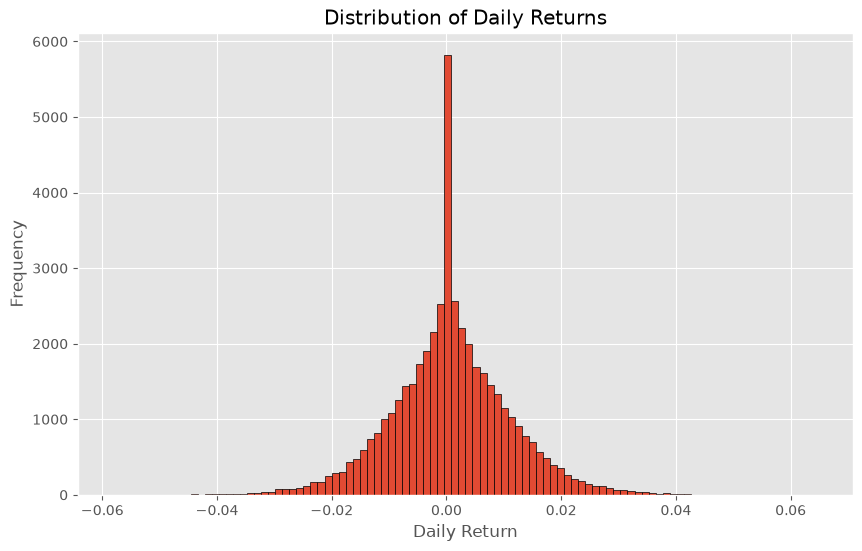

In [18]:
plt.figure(figsize=(10,6))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_3288\3598806211.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


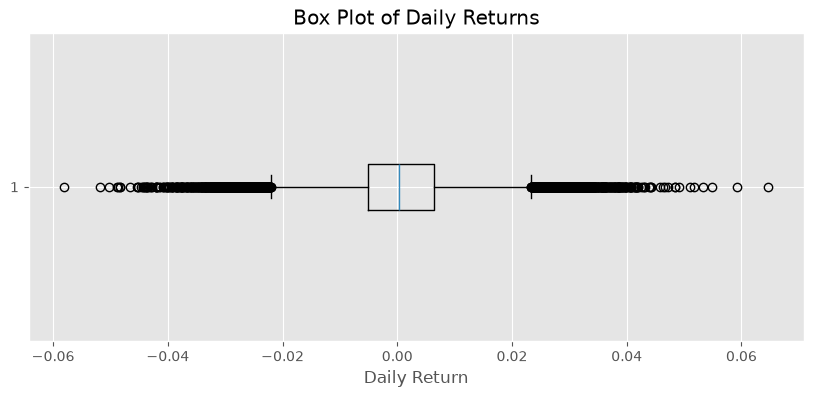

In [19]:
plt.figure(figsize=(10,4))

plt.boxplot(
    nav["daily_return"].dropna(),
    vert=False
)

plt.title("Box Plot of Daily Returns")
plt.xlabel("Daily Return")

plt.show()

In [20]:
nav.to_csv(
    "../data/processed/nav_with_daily_returns.csv",
    index=False
)

print("Daily returns saved successfully!")

Daily returns saved successfully!


In [21]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [22]:
cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    latest_date = group["date"].max()

    latest_nav = group.iloc[-1]["nav"]

    result = {"amfi_code": amfi_code}

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        past_data = group[group["date"] >= start_date]

        if len(past_data) > 0:

            start_nav = past_data.iloc[0]["nav"]

            result[f"CAGR_{years}Y"] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

        else:

            result[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

In [23]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [24]:
cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [25]:
cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

cagr_df.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039127
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.260741
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533


In [26]:
cagr_df.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [27]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [29]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    volatility = returns.std()

    sharpe = (
        (avg_return - daily_rf)
        / volatility
    ) * np.sqrt(252)

    sharpe_results.append(
        {
            "amfi_code": amfi_code,
            "Sharpe_Ratio": sharpe
        }
    )

sharpe_df = pd.DataFrame(sharpe_results)

In [30]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [31]:
sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (avg_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

In [32]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head()

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [33]:
risk_metrics = sharpe_df.merge(
    sortino_df,
    on="amfi_code"
)

risk_metrics = risk_metrics.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

risk_metrics = risk_metrics[
    [
        "amfi_code",
        "scheme_name",
        "Sharpe_Ratio",
        "Sortino_Ratio"
    ]
]

risk_metrics.head()

,amfi_code,scheme_name,Sharpe_Ratio,Sortino_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,2.385644
1,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.364320
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,2.146914
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,2.140267
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,2.029353


In [34]:
risk_metrics.to_csv(
    "../data/processed/risk_metrics.csv",
    index=False
)

print("Risk metrics saved successfully!")

Risk metrics saved successfully!


In [36]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["daily_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

In [37]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value,daily_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [38]:
merged_returns = nav.merge(
    nifty100[["date", "daily_return"]],
    on="date",
    how="inner",
    suffixes=("_fund", "_benchmark")
)

merged_returns.head()

,amfi_code,date,nav,daily_return_fund,daily_return_benchmark
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [39]:
alpha_beta_results = []

for amfi_code, group in merged_returns.groupby("amfi_code"):

    group = group.dropna()

    if len(group) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        group["daily_return_benchmark"],
        group["daily_return_fund"]
    )

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "Alpha": intercept * 252,
        "Beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

In [40]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [43]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha & Beta file saved successfully!")

Alpha & Beta file saved successfully!


In [44]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    max_drawdown = group["drawdown"].min()

    drawdown_results.append({
        "amfi_code": amfi_code,
        "Max_Drawdown": max_drawdown
    })

drawdown_df = pd.DataFrame(drawdown_results)

In [45]:
drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [46]:
worst_drawdown_dates = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    worst_row = group.loc[group["drawdown"].idxmin()]

    worst_drawdown_dates.append({
        "amfi_code": amfi_code,
        "Worst_Drawdown_Date": worst_row["date"],
        "Max_Drawdown": worst_row["drawdown"]
    })

worst_drawdown_df = pd.DataFrame(worst_drawdown_dates)

In [47]:
worst_drawdown_df.head()

,amfi_code,Worst_Drawdown_Date,Max_Drawdown
0,100016,2022-09-15,-0.247344
1,100025,2023-07-28,-0.043083
2,100033,2022-05-12,-0.162172
3,101206,2023-07-05,-0.112916
4,101207,2026-05-11,-0.354469


In [48]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

worst_drawdown_df.to_csv(
    "../data/processed/worst_drawdown_dates.csv",
    index=False
)

print("Drawdown files saved successfully!")

Drawdown files saved successfully!


In [49]:
performance_metrics = alpha_beta_df.merge(
    drawdown_df,
    on="amfi_code",
    how="inner"
)

performance_metrics.head()

,amfi_code,Alpha,Beta,Max_Drawdown
0,100016,0.037476,-0.058268,-0.247344
1,100025,0.042818,0.001158,-0.043083
2,100033,0.271954,0.005104,-0.162172
3,101206,0.213998,0.021086,-0.112916
4,101207,0.108971,-0.065289,-0.354469


In [50]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [51]:
drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [52]:
fund_scorecard = performance.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left",
    suffixes=("_given", "_calculated")
)

fund_scorecard = fund_scorecard.merge(
    drawdown_df,
    on="amfi_code",
    how="left"
)

fund_scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Alpha,Beta,Max_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,0.056209,-0.006414,-0.043287


In [53]:
fund_scorecard["Return_Rank"] = fund_scorecard["return_3yr_pct"].rank(ascending=False)

fund_scorecard["Sharpe_Rank"] = fund_scorecard["sharpe_ratio"].rank(ascending=False)

fund_scorecard["Alpha_Rank"] = fund_scorecard["Alpha"].rank(ascending=False)

fund_scorecard["Expense_Rank"] = fund_scorecard["expense_ratio_pct"].rank(ascending=True)

fund_scorecard["Drawdown_Rank"] = fund_scorecard["Max_Drawdown"].rank(ascending=False)

In [54]:
fund_scorecard["Fund_Score"] = (
      0.30 * fund_scorecard["Return_Rank"]
    + 0.25 * fund_scorecard["Sharpe_Rank"]
    + 0.20 * fund_scorecard["Alpha_Rank"]
    + 0.15 * fund_scorecard["Expense_Rank"]
    + 0.10 * fund_scorecard["Drawdown_Rank"]
)

fund_scorecard["Fund_Score"] = (
    100
    * (
        fund_scorecard["Fund_Score"]
        / fund_scorecard["Fund_Score"].max()
    )
)

In [55]:
fund_scorecard = fund_scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

fund_scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Alpha,Beta,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,0.91,0.85,1.25,14.0,-27.54,25803,1.64,4,Moderate,0.068995,0.009731,-0.144016,31.0,31.0,30.0,39.5,15.0,100.000000
20,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap,Regular,14.37,12.25,13.42,10.98,1.27,0.93,0.87,1.34,14.0,-17.86,35585,1.59,3,Moderate,0.130429,0.036356,-0.175736,28.0,29.0,25.0,35.0,24.0,92.863002
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,Regular,16.30,15.61,15.86,14.49,1.12,0.92,0.82,1.21,19.0,-13.43,41728,1.51,5,High,0.028969,-0.042125,-0.280011,12.0,33.5,40.0,24.5,35.0,89.089418
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate,0.177033,-0.040269,-0.138979,33.0,33.5,17.0,20.0,14.0,85.561936
25,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Large Cap,Direct,13.95,12.14,13.66,10.71,1.43,0.87,0.87,1.54,14.0,-17.40,15866,0.75,4,Moderate,0.082328,0.025883,-0.217514,29.0,29.0,28.0,8.0,31.0,84.823626
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,0.98,0.80,1.03,17.0,-22.62,2989,1.60,5,High,0.282704,0.018134,-0.163967,23.0,38.5,4.0,36.5,21.0,81.706317
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.198686,-0.026159,-0.118035,34.0,35.5,15.0,4.0,11.0,78.014766
37,149322,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,Regular,11.96,12.82,12.35,11.00,1.82,0.91,0.92,1.63,14.0,-21.70,41828,1.54,5,Moderate,0.131732,-0.004050,-0.148446,25.0,21.0,24.0,30.5,16.0,77.850697
31,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Index,Regular,13.76,12.10,11.31,11.17,0.93,0.90,0.93,1.29,13.0,-24.42,7350,1.57,4,Moderate,0.170488,-0.019487,-0.108599,30.0,19.5,19.0,34.0,7.0,77.030353
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High,0.119891,0.009054,-0.211173,14.0,38.5,26.0,10.0,29.0,76.866284


In [56]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved successfully!")

Fund scorecard saved successfully!


In [57]:
top5 = fund_scorecard.head(5)

top5[["scheme_name", "Fund_Score"]]

,scheme_name,Fund_Score
24,Axis Bluechip Fund - Regular - Growth,100.000000
20,Kotak Bluechip Fund - Regular - Growth,92.863002
32,UTI Mid Cap Fund - Regular - Growth,89.089418
10,ICICI Pru Bluechip Fund - Regular - Growth,85.561936
25,Axis Bluechip Fund - Direct - Growth,84.823626


In [58]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

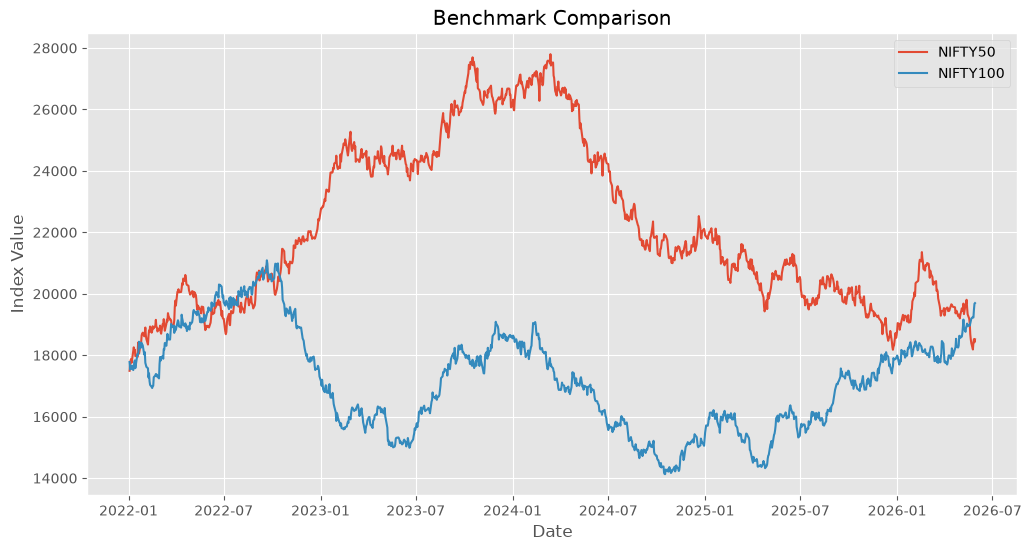

In [59]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    label="NIFTY100"
)

plt.title("Benchmark Comparison")

plt.xlabel("Date")

plt.ylabel("Index Value")

plt.legend()

plt.grid(True)

plt.show()

In [60]:
tracking_error = []

for amfi_code, group in merged_returns.groupby("amfi_code"):

    diff = (
        group["daily_return_fund"]
        - group["daily_return_benchmark"]
    )

    te = diff.std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": amfi_code,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [61]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("Tracking error saved successfully!")

Tracking error saved successfully!


In [62]:
drawdown_ranges = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    # Trough (maximum drawdown point)
    trough_idx = group["drawdown"].idxmin()

    trough_date = group.loc[trough_idx, "date"]

    max_drawdown = group.loc[trough_idx, "drawdown"]

    # Peak (last highest NAV before trough)
    peak_nav = group.loc[:trough_idx, "nav"].max()

    peak_date = group.loc[:trough_idx].loc[
        group.loc[:trough_idx, "nav"] == peak_nav,
        "date"
    ].iloc[-1]

    drawdown_ranges.append({
        "amfi_code": amfi_code,
        "Peak_Date": peak_date,
        "Trough_Date": trough_date,
        "Max_Drawdown": max_drawdown
    })

worst_drawdown_range = pd.DataFrame(drawdown_ranges)

worst_drawdown_range.head()

,amfi_code,Peak_Date,Trough_Date,Max_Drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [63]:
worst_drawdown_range.to_csv(
    "../data/processed/worst_drawdown_range.csv",
    index=False
)

print("Worst drawdown range saved successfully!")

Worst drawdown range saved successfully!


In [64]:
top5 = fund_scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Alpha,Beta,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,0.91,0.85,1.25,14.0,-27.54,25803,1.64,4,Moderate,0.068995,0.009731,-0.144016,31.0,31.0,30.0,39.5,15.0,100.000000
20,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap,Regular,14.37,12.25,13.42,10.98,1.27,0.93,0.87,1.34,14.0,-17.86,35585,1.59,3,Moderate,0.130429,0.036356,-0.175736,28.0,29.0,25.0,35.0,24.0,92.863002
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,Regular,16.30,15.61,15.86,14.49,1.12,0.92,0.82,1.21,19.0,-13.43,41728,1.51,5,High,0.028969,-0.042125,-0.280011,12.0,33.5,40.0,24.5,35.0,89.089418
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate,0.177033,-0.040269,-0.138979,33.0,33.5,17.0,20.0,14.0,85.561936
25,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Large Cap,Direct,13.95,12.14,13.66,10.71,1.43,0.87,0.87,1.54,14.0,-17.40,15866,0.75,4,Moderate,0.082328,0.025883,-0.217514,29.0,29.0,28.0,8.0,31.0,84.823626


In [65]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
8050,102886,2022-01-03,119.2905,NaN
8051,102886,2022-01-04,120.6402,0.011314
8052,102886,2022-01-05,121.4580,0.006779
8053,102886,2022-01-06,125.2386,0.031127
8054,102886,2022-01-07,124.1321,-0.008835


In [66]:
top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
            .transform(lambda x: x / x.iloc[0] * 100)
)

top5_nav.head()

,amfi_code,date,nav,daily_return,Normalized_NAV
8050,102886,2022-01-03,119.2905,NaN,100.000000
8051,102886,2022-01-04,120.6402,0.011314,101.131440
8052,102886,2022-01-05,121.4580,0.006779,101.816993
8053,102886,2022-01-06,125.2386,0.031127,104.986231
8054,102886,2022-01-07,124.1321,-0.008835,104.058664


NameError: name 'benchmark_chart' is not defined

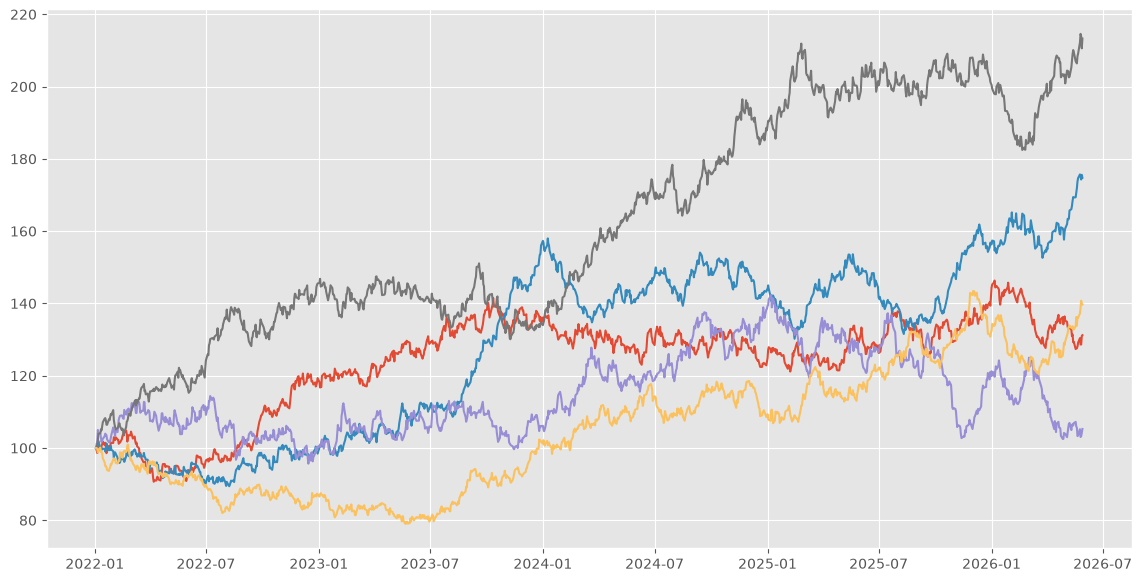

In [67]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for code in top5_codes:

    temp = top5_nav[top5_nav["amfi_code"] == code]

    name = top5.loc[
        top5["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=name
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_chart[
        benchmark_chart["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 vs NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [68]:
benchmark_chart = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_chart["Normalized_Index"] = (
    benchmark_chart.groupby("index_name")["close_value"]
                   .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_chart.head()

,date,index_name,close_value,daily_return,Normalized_Index
1150,2022-01-03,NIFTY100,17778.24,NaN,100.000000
1151,2022-01-04,NIFTY100,17537.52,-0.013540,98.645985
1152,2022-01-05,NIFTY100,17607.73,0.004003,99.040906
1153,2022-01-06,NIFTY100,17556.05,-0.002935,98.750214
1154,2022-01-07,NIFTY100,17664.02,0.006150,99.357529


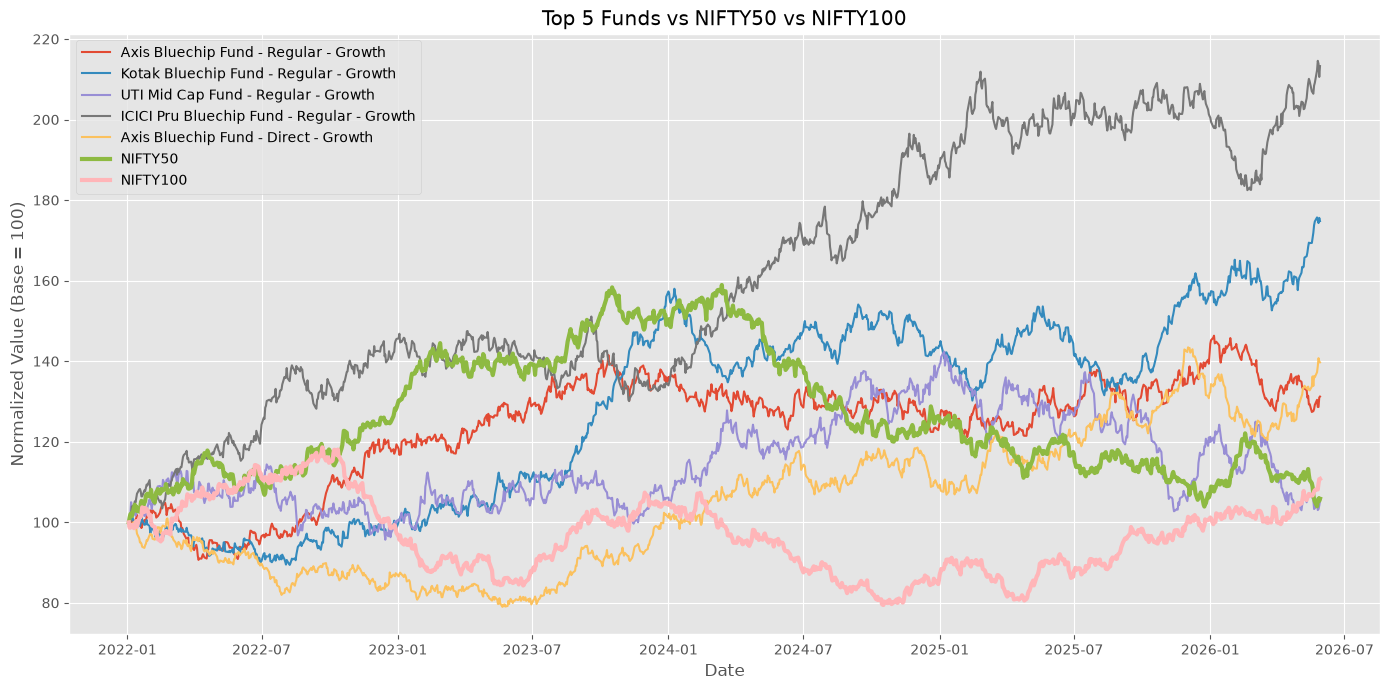

In [69]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for code in top5_codes:

    temp = top5_nav[top5_nav["amfi_code"] == code]

    name = top5.loc[
        top5["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=name
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_chart[
        benchmark_chart["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 vs NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()